Machine Learning Minor Project 2026;
 Learning Analyzer;
Srujan Bangera,Shravan Kumar and Shreyas.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("student_learning_dataset.csv")

In [4]:
df

,student_id,question_id,topic,difficulty,is_correct,time_taken,attempt_number
0,1,1,Trees,1,0,30.56,1
1,1,2,Dynamic Programming,1,0,27.97,3
2,1,3,Strings,1,0,33.29,3
3,1,4,Dynamic Programming,2,1,66.85,1
4,1,5,Arrays,1,1,30.46,3
...,...,...,...,...,...,...,...
11995,150,76,Dynamic Programming,2,0,118.67,1
11996,150,77,Arrays,3,0,183.76,1
11997,150,78,Trees,3,0,171.89,2
11998,150,79,Graphs,3,0,172.24,3


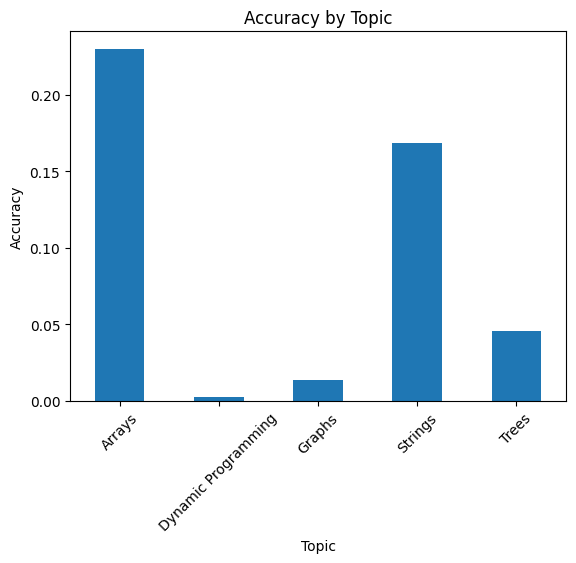

In [5]:
topic_acc = df.groupby("topic")["is_correct"].mean()

plt.figure()
topic_acc.plot(kind='bar')
plt.title("Accuracy by Topic")
plt.xlabel("Topic")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

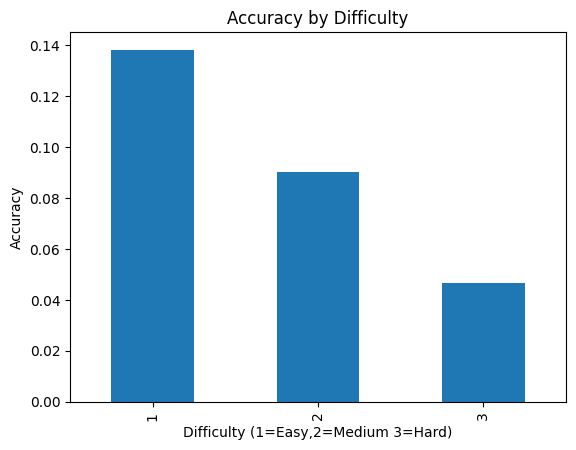

In [10]:
difficulty_acc = df.groupby("difficulty")["is_correct"].mean()

plt.figure()
difficulty_acc.plot(kind='bar')
plt.title("Accuracy by Difficulty")
plt.xlabel("Difficulty (1=Easy,2=Medium 3=Hard)")
plt.ylabel("Accuracy")
plt.show()

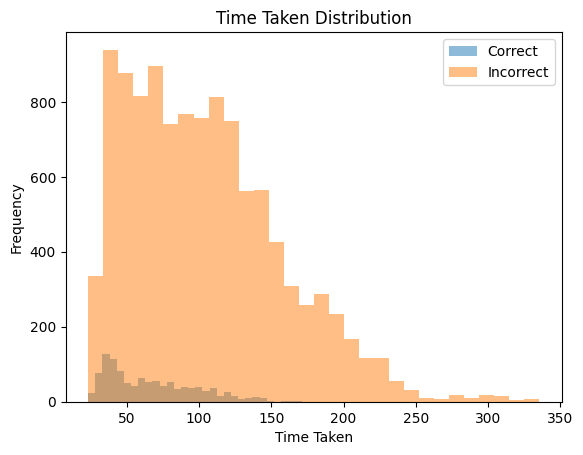

In [7]:
correct = df[df["is_correct"] == 1]["time_taken"]
incorrect = df[df["is_correct"] == 0]["time_taken"]

plt.figure()
plt.hist(correct, bins=30, alpha=0.5, label="Correct")
plt.hist(incorrect, bins=30, alpha=0.5, label="Incorrect")
plt.title("Time Taken Distribution")
plt.xlabel("Time Taken")
plt.ylabel("Frequency")
plt.legend()
plt.show()

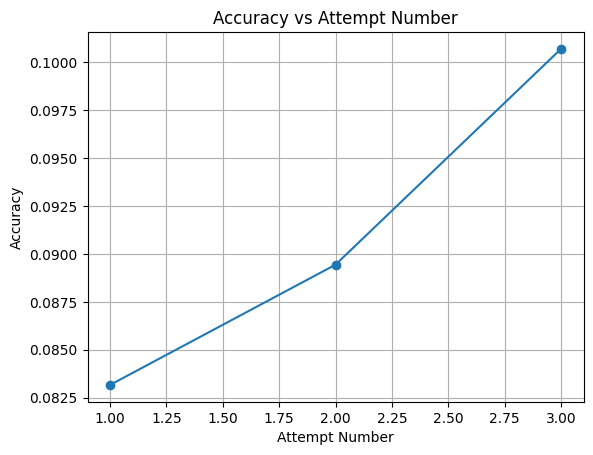

In [8]:
attempt_acc = df.groupby("attempt_number")["is_correct"].mean()

plt.figure()
attempt_acc.plot(kind='line', marker='o')
plt.title("Accuracy vs Attempt Number")
plt.xlabel("Attempt Number")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

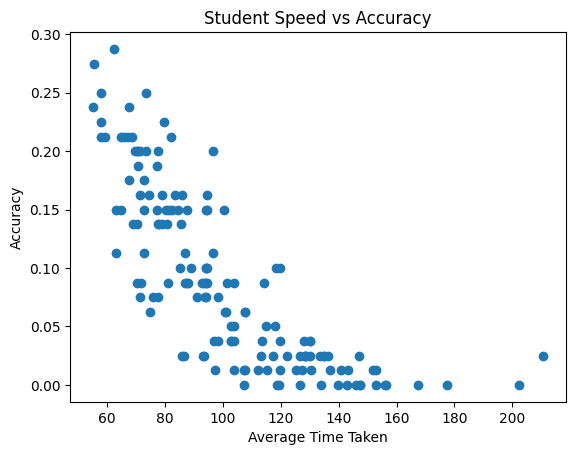

In [9]:
student_time = df.groupby("student_id")["time_taken"].mean()
student_acc = df.groupby("student_id")["is_correct"].mean()

plt.figure()
plt.scatter(student_time, student_acc)
plt.title("Student Speed vs Accuracy")
plt.xlabel("Average Time Taken")
plt.ylabel("Accuracy")
plt.show()

In [11]:
df.isnull().sum()

student_id        0
question_id       0
topic             0
difficulty        0
is_correct        0
time_taken        0
attempt_number    0
dtype: int64

In [12]:
df["time_taken"] = pd.to_numeric(df["time_taken"], errors="coerce")
df["difficulty"] = pd.to_numeric(df["difficulty"], errors="coerce")

In [13]:
df.isnull().sum()

student_id        0
question_id       0
topic             0
difficulty        0
is_correct        0
time_taken        0
attempt_number    0
dtype: int64

is_correct
0    10906
1     1094
Name: count, dtype: int64


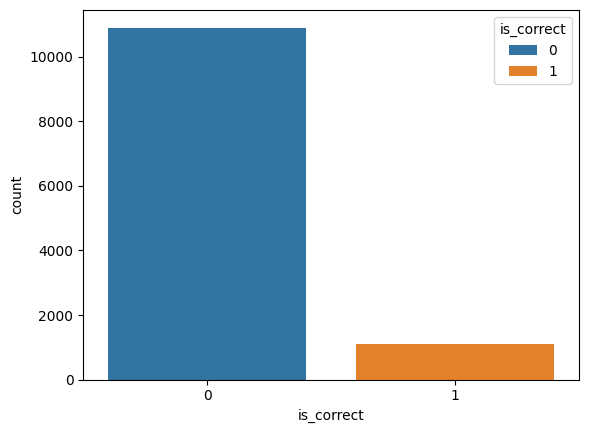

In [15]:
sns.countplot(data=df,x='is_correct',hue='is_correct')
print(df.is_correct.value_counts())

In [16]:
from sklearn.utils import resample

df_majority = df[df.is_correct == 0]
df_minority = df[df.is_correct == 1]

df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_balanced = pd.concat([df_majority_downsampled, df_minority])

In [17]:
df_balanced

,student_id,question_id,topic,difficulty,is_correct,time_taken,attempt_number
5049,64,10,Strings,3,0,221.05,3
7626,96,27,Dynamic Programming,2,0,121.64,2
963,13,4,Graphs,2,0,102.67,2
7953,100,34,Graphs,2,0,112.54,2
1577,20,58,Strings,2,0,86.69,2
...,...,...,...,...,...,...,...
11837,148,78,Arrays,1,1,32.85,3
11879,149,40,Arrays,1,1,74.78,1
11914,149,75,Arrays,2,1,162.65,1
11960,150,41,Arrays,3,1,171.54,3


is_correct
0    1094
1    1094
Name: count, dtype: int64


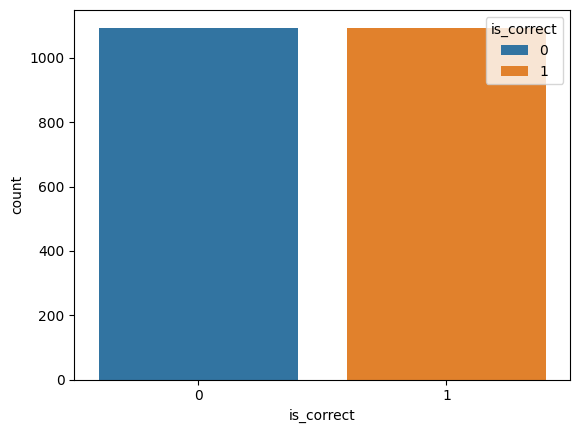

In [18]:
sns.countplot(data=df_balanced,x='is_correct',hue='is_correct')
print(df_balanced.is_correct.value_counts())

<Axes: xlabel='time_taken'>

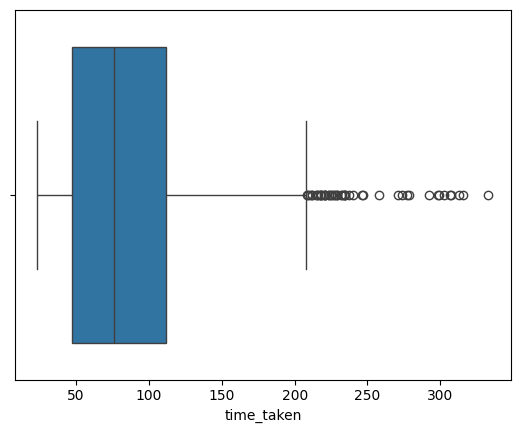

In [20]:
sns.boxplot(x=df_balanced["time_taken"])

<Axes: xlabel='attempt_number'>

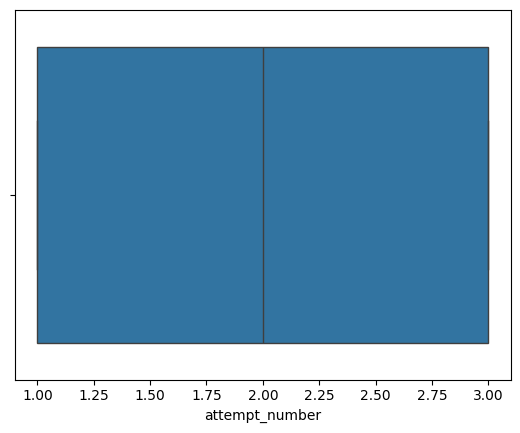

In [21]:
sns.boxplot(x=df_balanced["attempt_number"])

In [22]:
df_balanced["z_score"] = (
    (df_balanced["time_taken"] - df_balanced["time_taken"].mean()) 
    / df_balanced["time_taken"].std()
)

In [23]:
df_clean = df_balanced[df_balanced["z_score"].abs() < 3]

In [24]:
df_clean = df_clean.drop("z_score", axis=1)

<Axes: xlabel='time_taken'>

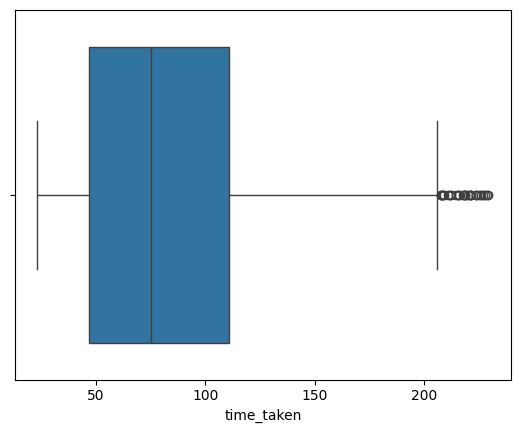

In [25]:
sns.boxplot(x=df_clean["time_taken"])

In [26]:
df_clean.shape

(2164, 7)

<Axes: >

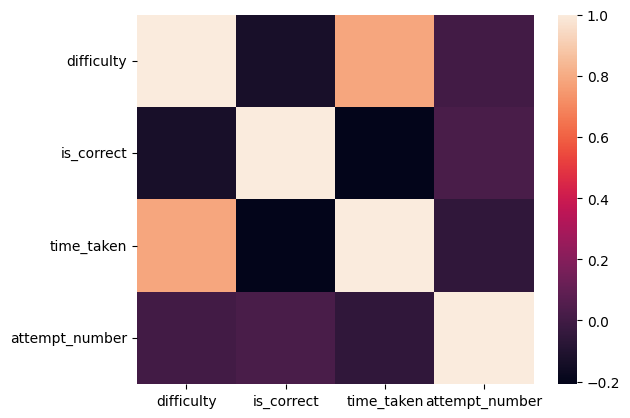

In [31]:
sns.heatmap(df[["difficulty", "is_correct", "time_taken", "attempt_number"]].corr(),fmt='.2g')

In [34]:
from sklearn.model_selection import train_test_split
X = pd.get_dummies(df_clean, columns=["topic"], drop_first=True)
y = X["is_correct"]
X = X.drop("is_correct", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

In [37]:
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print('F-1 Score : ',(f1_score(y_test, y_pred)))
print('Precision Score : ',(precision_score(y_test, y_pred)))
print('Recall Score : ',(recall_score(y_test, y_pred)))

Accuracy Score : 80.37 %
F-1 Score :  0.8148148148148148
Precision Score :  0.7695473251028807
Recall Score :  0.8657407407407407


Text(0.5, 1.0, 'Accuracy Score: 80.36951501154735')

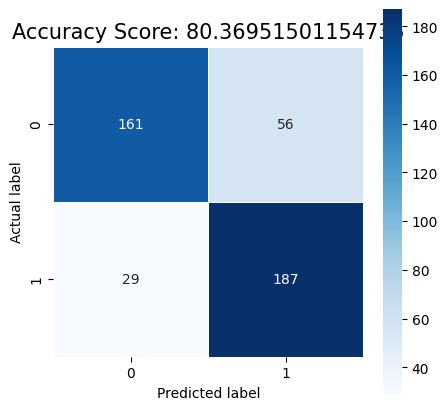

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5,fmt='d', annot=True,square = True, cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(model_lr.score(X_test, y_test)*100)
plt.title(all_sample_title, size = 15)

In [41]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

In [42]:
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print('F-1 Score : ',(f1_score(y_test, y_pred)))
print('Precision Score : ',(precision_score(y_test, y_pred)))
print('Recall Score : ',(recall_score(y_test, y_pred)))

Accuracy Score : 80.14 %
F-1 Score :  0.8162393162393162
Precision Score :  0.7579365079365079
Recall Score :  0.8842592592592593


Text(0.5, 1.0, 'Accuracy Score: 80.13856812933025')

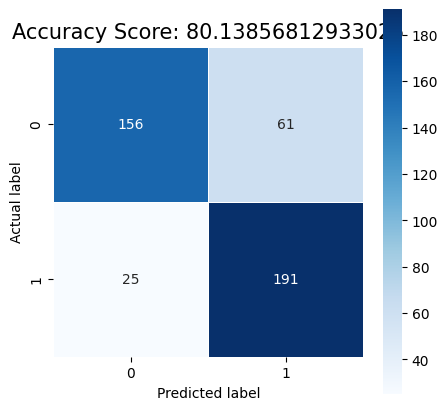

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5,fmt='d', annot=True,square = True, cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(model_rf.score(X_test, y_test)*100)
plt.title(all_sample_title, size = 15)

In [44]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)
y_pred = model_dt.predict(X_test)

In [45]:
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print('F-1 Score : ',(f1_score(y_test, y_pred)))
print('Precision Score : ',(precision_score(y_test, y_pred)))
print('Recall Score : ',(recall_score(y_test, y_pred)))

Accuracy Score : 79.68 %
F-1 Score :  0.8218623481781376
Precision Score :  0.7302158273381295
Recall Score :  0.9398148148148148


Text(0.5, 1.0, 'Accuracy Score: 79.67667436489607')

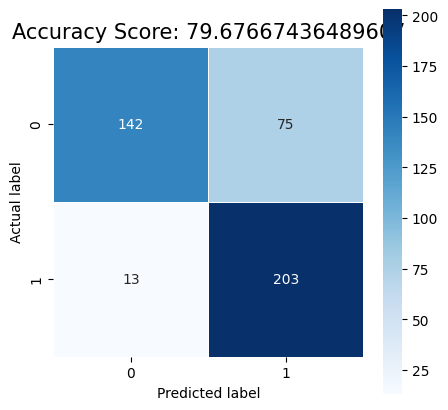

In [62]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5,fmt='d', annot=True,square = True, cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(model_dt.score(X_test, y_test)*100)
plt.title(all_sample_title, size = 15)

In [50]:
from sklearn import metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))

MAE is 0.20323325635103925
MSE is 0.20323325635103925
R2 score is 0.18706263867554207
RMSE score is 0.4508139930736836


In [63]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(random_state=0)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [64]:
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print('F-1 Score : ',(f1_score(y_test, y_pred)))
print('Precision Score : ',(precision_score(y_test, y_pred)))
print('Recall Score : ',(recall_score(y_test, y_pred)))

Accuracy Score : 77.6 %
F-1 Score :  0.7738927738927739
Precision Score :  0.7793427230046949
Recall Score :  0.7685185185185185


In [65]:
from sklearn import metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))

MAE is 0.22401847575057737
MSE is 0.22401847575057737
R2 score is 0.10392131763099521
RMSE score is 0.47330590081952006


Text(0.5, 1.0, 'Accuracy Score: 77.59815242494227')

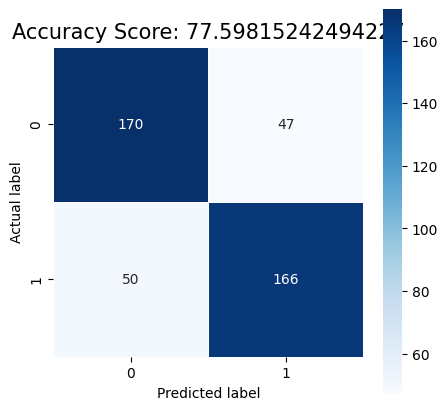

In [66]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5,fmt='d', annot=True,square = True, cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(ada.score(X_test, y_test)*100)
plt.title(all_sample_title, size = 15)